In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [ ]:
data=sns.load_dataset("titanic")
data.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


The data includes this data types bool(2), category(2), float64(2), int64(4) and object(5)

In [ ]:
data.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


There are pontential outliers in some columns when comparing the 75% and the max value,fare, age, sibsp and parch


In [ ]:
data.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


In [ ]:
#handling missing values , you can either dropping columns , filling in with mode, median and mean
#numerical values : fill in with the mean/median
#categorial valies : fill in with the mode
#Too many missing values in a column you can drop, more than 70%

In [ ]:
data['age'].fillna(data['age'].median(),inplace=True)# filling in the missing values with median
data['embarked'].fillna(data['embarked'].mode()[0],inplace=True)# filling in the missing values with mode

In [ ]:
data.drop(['deck','embark_town','alive','alone','who','class'],axis=1,inplace=True)
data.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,0
sibsp,0
parch,0
fare,0
embarked,0
adult_male,0


# EDA

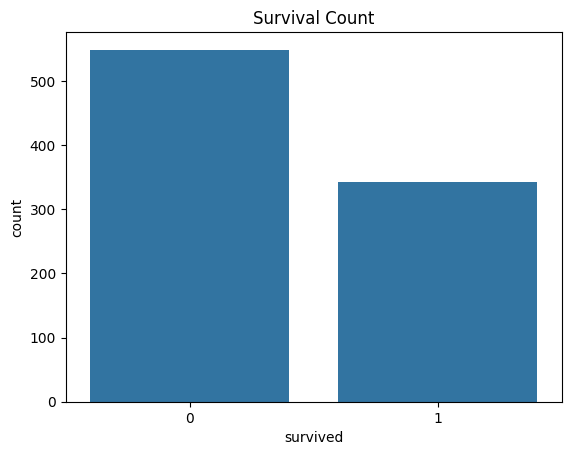

In [ ]:
#Survival Count
sns.countplot(x='survived',data=data)
plt.title("Survival Count")
plt.show()

There were less survivors indicating a class imbalance

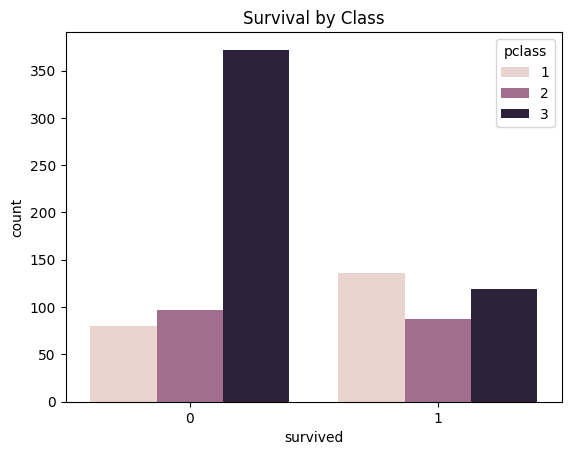

In [ ]:
sns.countplot(x='survived',data=data,hue='pclass')
plt.title("Survival by Class")
plt.show()

Most survivors were passenger class 1 followed by class 3 then 2.

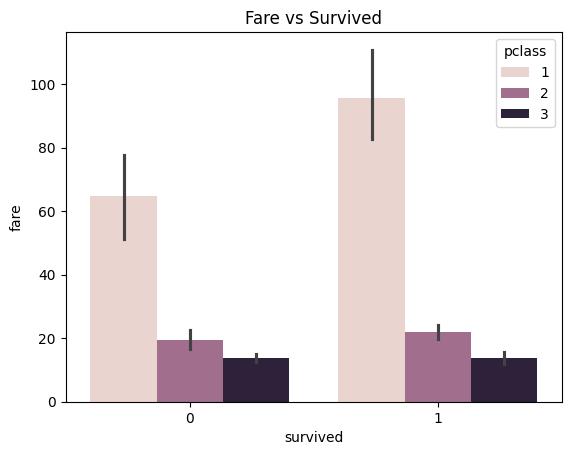

In [ ]:
#fare vs survived
sns.barplot(x='survived',y='fare',data=data,hue='pclass')
plt.title("Fare vs Survived")
plt.show()

Those who survived were mainly from passenger class 1 and had paid alot of fare

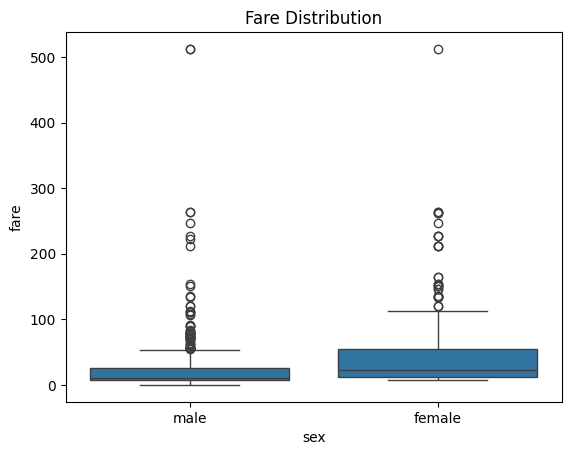

In [ ]:
#fare distribution
sns.boxplot(x='sex',y='fare',data=data)
plt.title("Fare Distribution")
plt.show()

There are considerable outliers in the fare column.

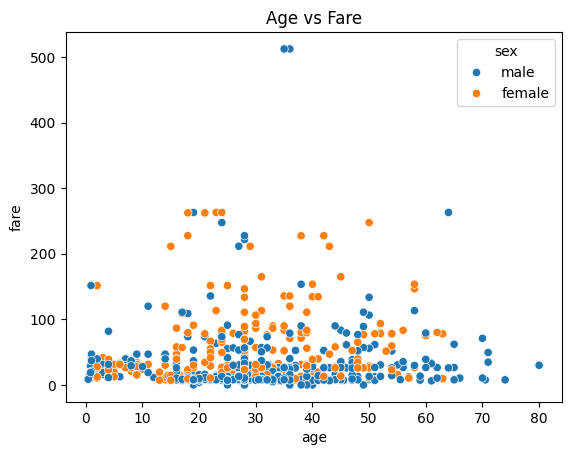

In [ ]:
#age vs fare scatterplot
sns.scatterplot(x='age',y='fare',data=data,hue='sex')
plt.title("Age vs Fare")
plt.show()

Females were likely to pay more than males.From age 35 we see more males than females in the data

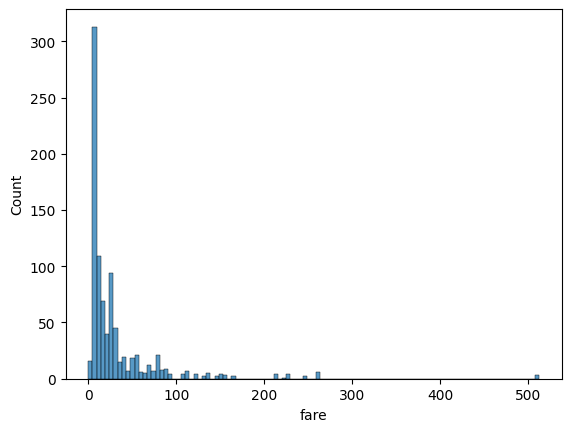

In [ ]:
#histogram of fare
sns.histplot(data=data,x='fare')
plt.show()

In [ ]:
data.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,adult_male
0,0,3,male,22.0,1,0,7.2500,S,True
1,1,1,female,38.0,1,0,71.2833,C,False
2,1,3,female,26.0,0,0,7.9250,S,False
3,1,1,female,35.0,1,0,53.1000,S,False
4,0,3,male,35.0,0,0,8.0500,S,True


In [ ]:
#Outlier detection and Removal IQR
def remove_outliers_iqr(data,column):
  Q1=data[column].quantile(0.25)
  Q3=data[column].quantile(0.75)
  IQR=Q3-Q1
  lower_bound=Q1-1.5*IQR
  upper_bound=Q3+1.5*IQR
  outliers=data[(data[column]<lower_bound) | (data[column]>upper_bound)]#Outlier detection
  cleaned=data[(data[column]>=lower_bound) & (data[column]<=upper_bound)] #Outlier Removal
  print(f'Outliers detected in {column}: {len(outliers)}')
  print(f"Before: {data.shape}, After removal: {cleaned.shape}")
  return cleaned

In [ ]:
cleaned_data_iqr=remove_outliers_iqr(data,'fare')

Outliers detected in fare: 116
Before: (891, 9), After removal: (775, 9)


In [ ]:
def remove_outliers_std(data,column,threshold=3):
  mean=data[column].mean()
  std=data[column].std()

  lower_bound=mean-threshold*std
  upper_bound=mean+threshold*std

  outliers=data[(data[column]<lower_bound) | (data[column]>upper_bound)]#Outlier detection
  cleaned=data[(data[column]>=lower_bound) & (data[column]<=upper_bound)] #Outlier Removal

  print(f'Outliers detected in {column}: {len(outliers)}')
  print(f"Before: {data.shape}, After removal: {cleaned.shape}")

  return cleaned

In [ ]:
cleaned_data_std= remove_outliers_std(data,'fare')

Outliers detected in fare: 20
Before: (891, 9), After removal: (871, 9)


In [ ]:
from scipy import stats

def remove_outliers_z(data,column,threshold=3):
  z_scores=stats.zscore(data[column])
  abs_z_scores=np.abs(z_scores)

  outliers=data[abs_z_scores>threshold]
  cleaned=data[abs_z_scores<=threshold]

  print(f'Outliers detected in {column}: {len(outliers)}')
  print(f"Before: {data.shape}, After removal: {cleaned.shape}")

  return cleaned


In [ ]:
cleaned_data_z=remove_outliers_z(data,'fare')

Outliers detected in fare: 20
Before: (891, 9), After removal: (871, 9)


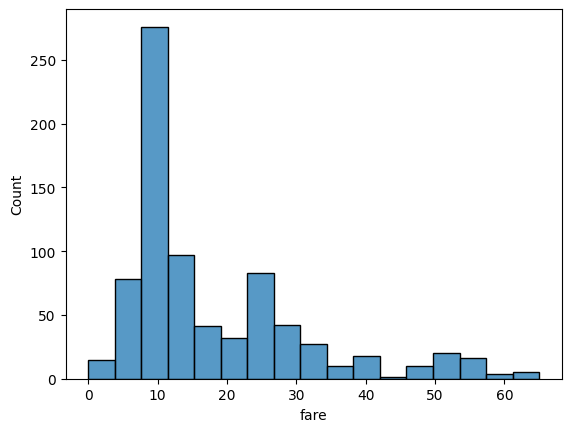

In [ ]:
sns.histplot(data=cleaned_data_iqr,x='fare')
plt.show()

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   survived    891 non-null    int64  
 1   pclass      891 non-null    int64  
 2   sex         891 non-null    object 
 3   age         891 non-null    float64
 4   sibsp       891 non-null    int64  
 5   parch       891 non-null    int64  
 6   fare        891 non-null    float64
 7   embarked    891 non-null    object 
 8   adult_male  891 non-null    bool   
dtypes: bool(1), float64(2), int64(4), object(2)
memory usage: 56.7+ KB


In [ ]:
#Correalation Heatmap : works only with numerical items
numeric_data=data.select_dtypes(include=['number'])
numeric_data.head()

,survived,pclass,age,sibsp,parch,fare
0,0,3,22.0,1,0,7.2500
1,1,1,38.0,1,0,71.2833
2,1,3,26.0,0,0,7.9250
3,1,1,35.0,1,0,53.1000
4,0,3,35.0,0,0,8.0500


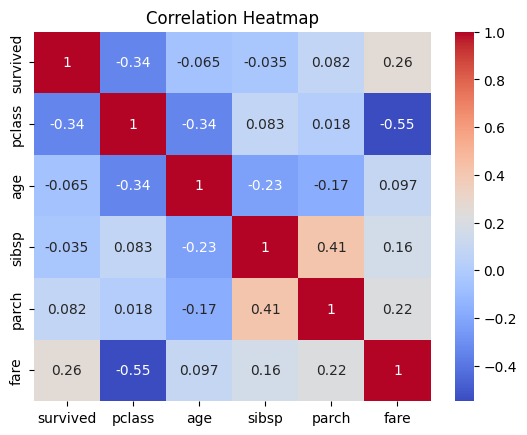

In [ ]:
sns.heatmap(numeric_data.corr(),annot=True,cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
#Multicollinearity

In [ ]:
#higher class passengers were more likely to survive as per pclass vs survived =-0.34
#A higher fare led to better channces of survival by 0.26
#Higher class passengers tended to pay more fares -0.55
#families tended to bring both spouses and children together 0.41


In [ ]:
#postive correaltion >0
#negative correaltion <0
#no to little correaltion close to 0 or at 0
#correlation range between -1, 0, 1

# Encoding

In [ ]:
#encoding converrting categorical data to numerical data
#Label encoding used on ordinal data

In [ ]:
from sklearn.preprocessing import LabelEncoder
data.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,adult_male
0,0,3,male,22.0,1,0,7.2500,S,True
1,1,1,female,38.0,1,0,71.2833,C,False
2,1,3,female,26.0,0,0,7.9250,S,False
3,1,1,female,35.0,1,0,53.1000,S,False
4,0,3,male,35.0,0,0,8.0500,S,True


In [ ]:
encoder=LabelEncoder()
data['sex_encoded']=encoder.fit_transform(data['sex'])
data.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,adult_male,sex_encoded
0,0,3,male,22.0,1,0,7.2500,S,True,1
1,1,1,female,38.0,1,0,71.2833,C,False,0
2,1,3,female,26.0,0,0,7.9250,S,False,0
3,1,1,female,35.0,1,0,53.1000,S,False,0
4,0,3,male,35.0,0,0,8.0500,S,True,1


In [ ]:
data['embarked'].unique()

array(['S', 'C', 'Q'], dtype=object)

S,c,q would be encoded to 0,1,2. this would affect the interpretation of the model by overemphsizing on postion 2 as it is higher than 0 and 1.

The label encoder maintains values in 1 column, it dose not create new columns

In [ ]:
#Dummy encoding
df=data.copy()
df=pd.get_dummies(df,columns=['embarked'])
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,adult_male,sex_encoded,embarked_C,embarked_Q,embarked_S
0,0,3,male,22.0,1,0,7.2500,True,1,False,False,True
1,1,1,female,38.0,1,0,71.2833,False,0,True,False,False
2,1,3,female,26.0,0,0,7.9250,False,0,False,False,True
3,1,1,female,35.0,1,0,53.1000,False,0,False,False,True
4,0,3,male,35.0,0,0,8.0500,True,1,False,False,True


In [ ]:
#ONE hot encoding, similar to dummy encoding
from sklearn.preprocessing import OneHotEncoder

encoder=OneHotEncoder()

encoded_data=encoder.fit_transform(data[['embarked']])


In [ ]:
encoded_data = pd.DataFrame(encoded_data.toarray(), columns=encoder.get_feature_names_out(['embarked']))
data = pd.concat([data.reset_index(drop=True), encoded_data], axis=1)
display(data.head())

,survived,pclass,sex,age,sibsp,parch,fare,embarked,adult_male,sex_encoded,embarked_C,embarked_Q,embarked_S
0,0,3,male,22.0,1,0,7.2500,S,True,1,0.0,0.0,1.0
1,1,1,female,38.0,1,0,71.2833,C,False,0,1.0,0.0,0.0
2,1,3,female,26.0,0,0,7.9250,S,False,0,0.0,0.0,1.0
3,1,1,female,35.0,1,0,53.1000,S,False,0,0.0,0.0,1.0
4,0,3,male,35.0,0,0,8.0500,S,True,1,0.0,0.0,1.0


Direct Mapping

In [ ]:
sex_map={'male':0,'female':1}#mapping
data['sex']=data['sex'].map(sex_map)#application of the mapping
data.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,adult_male,sex_encoded,embarked_C,embarked_Q,embarked_S
0,0,3,0,22.0,1,0,7.2500,S,True,1,0.0,0.0,1.0
1,1,1,1,38.0,1,0,71.2833,C,False,0,1.0,0.0,0.0
2,1,3,1,26.0,0,0,7.9250,S,False,0,0.0,0.0,1.0
3,1,1,1,35.0,1,0,53.1000,S,False,0,0.0,0.0,1.0
4,0,3,0,35.0,0,0,8.0500,S,True,1,0.0,0.0,1.0


In [ ]:
embarked_map={'S':0,'C':1,'Q':2}
data['embarked']=data['embarked'].map(embarked_map)
data.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,adult_male,sex_encoded,embarked_C,embarked_Q,embarked_S
0,0,3,0,22.0,1,0,7.2500,0,True,1,0.0,0.0,1.0
1,1,1,1,38.0,1,0,71.2833,1,False,0,1.0,0.0,0.0
2,1,3,1,26.0,0,0,7.9250,0,False,0,0.0,0.0,1.0
3,1,1,1,35.0,1,0,53.1000,0,False,0,0.0,0.0,1.0
4,0,3,0,35.0,0,0,8.0500,0,True,1,0.0,0.0,1.0
